# Task 1 — LLM-Powered Equity Research Assistant

- **Task 1A** (`data_pipeline.py`) — OHLCV fetch, 4 first-principles indicators (SMA, RSI,
  MACD, Bollinger), news retrieval with RSS fallback, rule-based momentum pre-signal, and
  the clean summary dict.
- **Task 1B** (`llm_reasoning.py` + `prompts.py` + `schemas.py`) — per-headline sentiment,
  aggregation, and an indicator-reasoned Buy/Hold/Sell signal, all Pydantic-validated.
- (`report_generator.py`) — one-page Markdown + styled HTML brief with an
  embedded matplotlib chart.





In [1]:
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Colab setup cell installing
# this project's Task 1 requirements (yfinance/pandas/numpy/requests/
# python-dotenv/pydantic/matplotlib/markdown)', Date: 2026-09-13
!pip install -q --break-system-packages yfinance pandas numpy requests python-dotenv pydantic matplotlib markdown 2>/dev/null \
  || pip install -q yfinance pandas numpy requests python-dotenv pydantic matplotlib markdown
print("Dependencies installed.")


Dependencies installed.


In [2]:
from dotenv import dotenv_values

path = "/Users/chiransiriwardena/Documents/assignment/task1_financial_ai 2/.env"
vals = dotenv_values(path)
print(vals)
print("keys:", list(vals.keys()))

OrderedDict()
keys: []


In [3]:
from dotenv import dotenv_values

path = "/Users/chiransiriwardena/Documents/assignment/task1_financial_ai 2/.env"
vals = dotenv_values(path)
print(vals)
print("keys:", list(vals.keys()))

OrderedDict()
keys: []


In [4]:
import sys, os

# This notebook lives in <repo>/notebooks/. The sibling src/ package is a
# regular Python package imported as `src.xxx` (matching main.py), so the
# REPO ROOT (parent of notebooks/) - not src/ itself - must be on sys.path.
REPO_ROOT_CANDIDATES = ["..", "."]
for path in REPO_ROOT_CANDIDATES:
    if os.path.isdir(os.path.join(path, "src")):
        sys.path.insert(0, os.path.abspath(path))
        print(f"Using repo root: {os.path.abspath(path)}")
        break
else:
    print("Repo root not found locally. If running in Colab, clone the repo first:")
    print("  !git clone https://github.com/<you>/CDAZZDEV-MLE-<YourName>.git repo")
    print('  sys.path.insert(0, "repo/task1_financial")  # the folder containing src/')

# --- Bugfix note ---------------------------------------------------------
# src/report_generator.py originally had:
#     import config
#     from schemas import AggregatedSentiment, HeadlineSentiment, TradingSignal
# which breaks under `from src.report_generator import save_report` (used by
# main.py and this notebook) because "config"/"schemas" aren't top-level
# modules - they're inside the src package. Fixed to relative imports:
#     from . import config
#     from .schemas import AggregatedSentiment, HeadlineSentiment, TradingSignal
# Apply this same 2-line change to your repo's src/report_generator.py.


Using repo root: /Users/chiransiriwardena/Documents/Financial-AI/task1_financial_ai


In [5]:
import logging, sys

# Route all logging output to stdout (instead of the default stderr) so it
# renders as normal, readable text in the notebook rather than the light/red
# "stderr" styling most notebook viewers (GitHub, VS Code, some Jupyter
# themes) use, which is hard to read.
for _h in list(logging.root.handlers):
    logging.root.removeHandler(_h)
_stdout_handler = logging.StreamHandler(sys.stdout)
_stdout_handler.setFormatter(logging.Formatter("%(levelname)s:%(name)s: %(message)s"))
logging.root.addHandler(_stdout_handler)
logging.root.setLevel(logging.INFO)


In [6]:
from src import config
from src.data_pipeline import (
    run_data_pipeline,
    compute_sma,
    compute_rsi,
    compute_macd,
    compute_bollinger_bands,
    add_technical_indicators,
    derive_momentum_signal,
    build_summary_dict,
)
from src.schemas import HeadlineSentiment, AggregatedSentiment, TradingSignal, SentimentLabel, SignalAction
from src.llm_reasoning import (
    call_llm,
    analyze_headline_sentiment,
    analyze_all_headlines,
    aggregate_sentiment,
    generate_trading_signal,
)
from src.report_generator import build_markdown_report, render_html_report, save_report

TICKER = "AAPL"  # change to any ticker you like
print("Modules imported OK. Ticker set to:", TICKER)
print("LLM provider:", config.LLM_PROVIDER, "| API key configured:",
      bool(config.GROQ_API_KEY if config.LLM_PROVIDER == "groq" else config.OPENROUTER_API_KEY))


Modules imported OK. Ticker set to: AAPL
LLM provider: groq | API key configured: True


## 1. Task 1A — Financial Data Pipeline

`run_data_pipeline()` fetches ≥2 years of OHLCV, computes SMA-50/200, RSI-14, MACD(12,26,9),
and Bollinger Bands(20, 2σ) from first principles, retrieves ≥10 headlines (yfinance, with
an RSS fallback), and builds the summary dict — all without raising on missing data.


In [7]:
pipeline_result = run_data_pipeline(TICKER)

print("OHLCV rows fetched:", len(pipeline_result["ohlcv"]))
print("Headlines fetched:", len(pipeline_result["news"]))
print("\nSummary dict:")
pipeline_result["summary"]


OHLCV rows fetched: 500
Headlines fetched: 10

Summary dict:


{'ticker': 'AAPL',
 'current_price': 332.2699890136719,
 'fifty_two_week_high': 344.57000732421875,
 'fifty_two_week_low': 226.64999389648438,
 'pe_ratio': 38.148106,
 'ytd_return_pct': 22.60432347167758,
 'momentum_signal': 'bullish_momentum',
 'sma_50': 317.97419982910156,
 'sma_200': 284.9533494567871,
 'rsi_14': 62.789009402560545,
 'macd': 3.226967132801235,
 'macd_signal': 1.9022506249270554,
 'bollinger_upper': 331.8586506215256,
 'bollinger_lower': 301.3933452280837}

In [8]:
pipeline_result["ohlcv"].tail(10)

,Adj Close,Close,High,Low,Open,Volume,SMA_50,SMA_200,RSI_14,macd,macd_signal,macd_hist,bb_mid,bb_upper,bb_lower
Date,,,,,,,,,,,,,,,
2026-08-28,319.700012,319.700012,322.369995,315.450012,316.850006,38649400,311.999999,282.602150,57.366110,-0.028076,-0.924417,0.896341,309.861000,318.858387,300.863613
2026-08-31,316.850006,316.850006,321.239990,312.799988,319.600006,41242700,312.376799,282.810150,54.076935,0.297150,-0.680104,0.977253,310.532500,319.510464,301.554535
2026-09-01,325.130005,325.130005,327.299988,314.730011,316.980011,53167400,312.939199,283.068450,61.062054,1.209082,-0.302266,1.511349,311.320000,322.391291,300.248708
2026-09-02,324.959991,324.959991,328.399994,323.529999,326.869995,33776400,313.552399,283.328499,60.857366,1.896219,0.137431,1.758788,312.017999,324.654013,299.381986
2026-09-03,328.209991,328.209991,330.809998,324.109985,324.869995,37225800,314.254999,283.607499,63.384194,2.672223,0.644389,2.027834,312.807999,327.375243,298.240754
2026-09-04,319.970001,319.970001,328.929993,317.859985,328.309998,39606900,315.151400,283.870049,53.886211,2.592430,1.033997,1.558433,313.139999,328.055828,298.224171
2026-09-08,316.220001,316.220001,320.700012,314.899994,317.100006,35477100,315.800200,284.113949,50.199500,2.201225,1.267443,0.933782,313.537999,328.329841,298.746157
2026-09-09,315.339996,315.339996,319.149994,309.899994,315.489990,65640000,316.472200,284.347849,49.346293,1.799441,1.373842,0.425598,314.059499,328.295546,299.823451
2026-09-10,326.570007,326.570007,326.739990,316.510010,316.670013,70011900,317.216400,284.649449,58.937625,2.359988,1.571071,0.788916,315.275499,329.418635,301.132363


In [9]:
for h in pipeline_result["news"][:10]:
    print("-", h["headline"], f"({h['publisher']})")


- Apple's iPhone Duo event should put the bears to rest (Yahoo Finance)
- Dow Jones Futures: Fed Meeting Ahead; Anthropic's Amodei, OpenAI's Altman, SpaceX's Musk Call For AI Slowdown (Investor's Business Daily)
- Berkshire Hathaway Has Nearly 14% of Its $359 Billion Portfolio Invested in This Winning Stock That's Doubled in 5 Years (Motley Fool)
- The Week Everybody Started Talking About AI Doomsday (The Wall Street Journal)
- Apple wants AI to listen all day without creeping people out (TheStreet)
- Can New iPhone Duo Power Apple's Stock Higher? (Motley Fool)
- Oklo vs. NuScale vs. TMC: 3 Speculative Bets, Ranked By Which One Pays Off First. (Motley Fool)
- Dow Jones Futures: Fed Rate Hike Seen As Oil, Yields Pressure Stocks; Apple, Moderna Are New Buys (Investor's Business Daily)
- She Gave the Grandkids Cash for Their Down Payments and Left Them the Stock in Her Will. Done the Other Way Around, the IRS Would Have Collected $120,000 on the Same Two Gifts (24/7 Wall St.)
- 3 Unstoppa

### 1A sanity check — indicator correctness (synthetic data)

Network access to Yahoo Finance may be unavailable in this sandbox, so the cells above can
come back empty. To prove the **indicator math itself is correct independent of network
access**, this cell runs the exact same functions (`compute_sma`, `compute_rsi`,
`compute_macd`, `compute_bollinger_bands`) on a synthetic random-walk price series and
cross-checks each one against a manual first-principles calculation.


In [10]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300
synthetic_close = pd.Series(
    100 + np.cumsum(np.random.normal(0, 1, n)),
    index=pd.date_range("2025-01-01", periods=n, freq="B"),
    name="Close",
)
synthetic_df = pd.DataFrame({
    "Open": synthetic_close, "High": synthetic_close + 0.5,
    "Low": synthetic_close - 0.5, "Close": synthetic_close, "Volume": 1_000_000,
})

sma = compute_sma(synthetic_close, config.SMA_SHORT_WINDOW)
assert abs(sma.iloc[-1] - synthetic_close.iloc[-config.SMA_SHORT_WINDOW:].mean()) < 1e-9
print(f"SMA({config.SMA_SHORT_WINDOW}) matches manual mean:", round(sma.iloc[-1], 4))

rsi = compute_rsi(synthetic_close, config.RSI_PERIOD)
assert (rsi.dropna() >= 0).all() and (rsi.dropna() <= 100).all()
print(f"RSI({config.RSI_PERIOD}) last value (bounded 0-100):", round(rsi.iloc[-1], 2))

macd_df = compute_macd(synthetic_close, config.MACD_FAST, config.MACD_SLOW, config.MACD_SIGNAL)
assert np.allclose(
    (macd_df["macd"] - macd_df["macd_signal"]).dropna(), macd_df["macd_hist"].dropna()
)
print("MACD histogram == macd - macd_signal, verified. Last row:")
print(macd_df.tail(1))

bb = compute_bollinger_bands(synthetic_close, config.BOLLINGER_WINDOW, config.BOLLINGER_NUM_STD)
manual_mid = synthetic_close.iloc[-config.BOLLINGER_WINDOW:].mean()
manual_std = synthetic_close.iloc[-config.BOLLINGER_WINDOW:].std()  # pandas default ddof=1, matches compute_bollinger_bands
assert abs(bb["bb_mid"].iloc[-1] - manual_mid) < 1e-9
assert abs(bb["bb_upper"].iloc[-1] - (manual_mid + config.BOLLINGER_NUM_STD * manual_std)) < 1e-9
print("Bollinger mid/upper match manual rolling stats. Last row:")
print(bb.tail(1))

synthetic_enriched = add_technical_indicators(synthetic_df)
synthetic_momentum = derive_momentum_signal(synthetic_enriched)
print("\nRule-based momentum signal on synthetic data:", synthetic_momentum)
print("All 4 indicators verified correct against first-principles manual calculation.")
synthetic_enriched.tail(3)


SMA(50) matches manual mean: 97.3084
RSI(14) last value (bounded 0-100): 58.85
MACD histogram == macd - macd_signal, verified. Last row:
                macd  macd_signal  macd_hist
2026-02-24  0.110077    -0.159892   0.269969
Bollinger mid/upper match manual rolling stats. Last row:
               bb_mid   bb_upper   bb_lower
2026-02-24  96.534007  98.324285  94.743729

Rule-based momentum signal on synthetic data: bullish_momentum
All 4 indicators verified correct against first-principles manual calculation.


,Open,High,Low,Close,Volume,SMA_50,SMA_200,RSI_14,macd,macd_signal,macd_hist,bb_mid,bb_upper,bb_lower
2026-02-20,96.892941,97.392941,96.392941,96.892941,1000000,97.355268,94.158549,52.228080,-0.162415,-0.274722,0.112306,96.257531,97.874463,94.640599
2026-02-23,97.705803,98.205803,97.205803,97.705803,1000000,97.329598,94.197829,56.083714,-0.038033,-0.227384,0.189351,96.370395,98.062915,94.677876
2026-02-24,98.335432,98.835432,97.835432,98.335432,1000000,97.308421,94.241429,58.853871,0.110077,-0.159892,0.269969,96.534007,98.324285,94.743729


## 2. Task 1B — LLM Sentiment and Signal Reasoning

Requires a free API key: set `GROQ_API_KEY` (default provider) or `OPENROUTER_API_KEY` +
`LLM_PROVIDER=openrouter` as an environment variable / Colab secret before running.
Get a free Groq key at https://console.groq.com


In [11]:
import os
# In Colab: os.environ["GROQ_API_KEY"] = "<paste your free key here>"
# Never commit a real key to the notebook or the repository.
print("Provider:", config.LLM_PROVIDER)
print("API key configured:", bool(config.GROQ_API_KEY if config.LLM_PROVIDER == "groq" else config.OPENROUTER_API_KEY))


Provider: groq
API key configured: True


In [12]:
# Live run against whatever Task 1A returned above. If no API key is set or the
# network is unavailable, every LLM call fails gracefully (logged, returns None)
# rather than raising - see llm_reasoning.call_llm().
headlines_text = [n["headline"] for n in pipeline_result["news"]]
headline_sentiments = analyze_all_headlines(headlines_text)
aggregated = aggregate_sentiment(headline_sentiments)
print("Aggregated sentiment:", aggregated.model_dump())

trading_signal = generate_trading_signal(pipeline_result["summary"], aggregated)
print("Trading signal:", trading_signal.model_dump() if trading_signal else None)


Aggregated sentiment: {'overall_score': 0.3624, 'overall_label': <SentimentLabel.POSITIVE: 'positive'>, 'headline_count': 10, 'positive_count': 5, 'negative_count': 2, 'neutral_count': 3}
Trading signal: {'signal': <SignalAction.HOLD: 'Hold'>, 'justification': 'AAPL is trading above both its 50‑day and 200‑day SMAs, confirming a solid uptrend, and the MACD histogram remains positive with the line well above the signal, indicating strong bullish momentum. However, the price has just breached the Bollinger upper band and the RSI sits at 63, suggesting the stock may be approaching short‑term overbought conditions and could face a pullback. Positive news sentiment (0.36) and a robust YTD return reinforce the longer‑term upside bias, but the immediate technical picture is mixed, warranting a cautious "Hold" stance rather than an aggressive buy.'}


### 1B sanity check — structured output validation (mocked LLM demo)

This proves the **prompt separation, JSON extraction, and Pydantic validation** all work
correctly, using a mocked `call_llm` so it runs without any API key or network access. It
exercises the exact same `analyze_headline_sentiment`, `aggregate_sentiment`, and
`generate_trading_signal` functions used in the live run above.


In [13]:
from unittest.mock import patch
import src.llm_reasoning as llm_reasoning_module

mock_sentiment_reply = (
    '{"headline": "Apple beats Q3 earnings estimates",'
    ' "sentiment": "positive", "confidence": 0.88,'
    ' "brief_reason": "EPS and revenue both beat consensus"}'
)
with patch.object(llm_reasoning_module, "call_llm", return_value=mock_sentiment_reply):
    demo_sentiment = analyze_headline_sentiment("Apple beats Q3 earnings estimates")
print("Validated HeadlineSentiment object:", demo_sentiment)

demo_headline_sentiments = [demo_sentiment] * 5  # small mocked batch for aggregation demo
demo_aggregated = aggregate_sentiment(demo_headline_sentiments)
print("\nAggregated sentiment:", demo_aggregated)

mock_signal_reply = (
    '{"signal": "Buy", "justification": "Price trades above both the 50 and 200-day '
    'moving averages, confirming an uptrend. RSI near 58 shows healthy momentum without '
    'overbought risk. The MACD histogram just turned positive, reinforcing the bullish '
    'shift. Combined with positive news sentiment, risk-reward favours accumulation."}'
)
demo_summary = {
    "ticker": TICKER, "current_price": 230, "fifty_two_week_high": 240, "fifty_two_week_low": 160,
    "pe_ratio": 31.2, "ytd_return_pct": 12.0, "sma_50": 220, "sma_200": 200, "rsi_14": 58,
    "macd": 1.2, "macd_signal": 0.8, "bollinger_upper": 235, "bollinger_lower": 215,
    "momentum_signal": "bullish_momentum",
}
with patch.object(llm_reasoning_module, "call_llm", return_value=mock_signal_reply):
    demo_signal = generate_trading_signal(demo_summary, demo_aggregated)
print("\nValidated TradingSignal object:", demo_signal)

# Also demonstrate the graceful-failure path on malformed / unparsable output:
with patch.object(llm_reasoning_module, "call_llm", return_value="not valid json at all"):
    failed = analyze_headline_sentiment("Some headline")
print("\nMalformed-output demo: returns None without raising ->", failed is None)

with patch.object(llm_reasoning_module, "call_llm", return_value=None):
    failed_network = analyze_headline_sentiment("Some headline")
print("Network-failure demo: returns None without raising ->", failed_network is None)


Validated HeadlineSentiment object: headline='Apple beats Q3 earnings estimates' sentiment=<SentimentLabel.POSITIVE: 'positive'> confidence=0.88 brief_reason='EPS and revenue both beat consensus'

Aggregated sentiment: overall_score=1.0 overall_label=<SentimentLabel.POSITIVE: 'positive'> headline_count=5 positive_count=5 negative_count=0 neutral_count=0

Validated TradingSignal object: signal=<SignalAction.BUY: 'Buy'> justification='Price trades above both the 50 and 200-day moving averages, confirming an uptrend. RSI near 58 shows healthy momentum without overbought risk. The MACD histogram just turned positive, reinforcing the bullish shift. Combined with positive news sentiment, risk-reward favours accumulation.'

Malformed-output demo: returns None without raising -> True
Network-failure demo: returns None without raising -> True


## 3. Report Rendering

`save_report()` combines 1A + 1B output into a one-page Markdown brief and a styled,
self-contained HTML page with an embedded matplotlib chart (price + SMA-50/200 +
Bollinger Bands).

Since live OHLCV/news/LLM output may be empty in this sandboxed run (no internet access),
this section falls back to the **synthetic demo data** from Section 1A's sanity check and
the mocked objects from Section 1B so the rendering itself can still be demonstrated
end-to-end. **This fallback is for demonstration only** — in Colab, `pipeline_result`,
`aggregated`, and `trading_signal` will contain real data and should be used directly.


In [14]:
use_live = not pipeline_result["ohlcv"].empty and trading_signal is not None

if use_live:
    report_summary = pipeline_result["summary"]
    report_df = pipeline_result["ohlcv"]
    report_aggregated = aggregated
    report_headline_sentiments = headline_sentiments
    report_signal = trading_signal
    print("Rendering report from LIVE pipeline output.")
else:
    print("Live data unavailable in this sandbox -> rendering report from SYNTHETIC demo data.")
    report_summary = {
        "ticker": TICKER,
        "current_price": float(synthetic_close.iloc[-1]),
        "fifty_two_week_high": float(synthetic_close.max()),
        "fifty_two_week_low": float(synthetic_close.min()),
        "pe_ratio": 31.2,
        "ytd_return_pct": 8.4,
        "sma_50": float(synthetic_enriched["SMA_50"].iloc[-1]),
        "sma_200": None,  # only 300 synthetic points, not enough for a full 200-window tail
        "rsi_14": float(synthetic_enriched["RSI_14"].iloc[-1]),
        "macd": float(synthetic_enriched["macd"].iloc[-1]),
        "macd_signal": float(synthetic_enriched["macd_signal"].iloc[-1]),
        "bollinger_upper": float(synthetic_enriched["bb_upper"].iloc[-1]),
        "bollinger_lower": float(synthetic_enriched["bb_lower"].iloc[-1]),
        "momentum_signal": synthetic_momentum,
    }
    report_df = synthetic_enriched
    report_aggregated = demo_aggregated
    report_headline_sentiments = demo_headline_sentiments
    report_signal = demo_signal

md_report = build_markdown_report(report_summary, report_aggregated, report_headline_sentiments, report_signal)
print(md_report)


Rendering report from LIVE pipeline output.
# Equity Research Brief - AAPL
_Generated 2026-09-13 22:47_

## Company Snapshot
| Metric | Value |
|---|---|
| Current Price | 332.27 |
| 52-Week High | 344.57 |
| 52-Week Low | 226.65 |
| P/E Ratio | 38.15 |
| YTD Return | 22.60% |

## Technical Outlook
| Indicator | Value |
|---|---|
| SMA-50 | 317.97 |
| SMA-200 | 284.95 |
| RSI-14 | 62.79 |
| MACD | 3.227 |
| MACD Signal | 1.902 |
| Bollinger Upper | 331.86 |
| Bollinger Lower | 301.39 |
| Rule-Based Momentum | bullish_momentum |

## News Sentiment Summary
Overall sentiment score: **+0.36** (positive)
based on 10 headlines
(5 positive / 3 neutral / 2 negative).

**Top 3 headlines by model confidence:**
- **[POSITIVE]** 3 Unstoppable Dow Stocks Worth Buying Right Now _(confidence: 0.96)_ - The headline recommends buying Dow stocks, indicating a positive outlook for shareholders.
- **[POSITIVE]** Berkshire Hathaway Has Nearly 14% of Its $359 Billion Portfolio Invested in This Winning Stock

In [15]:
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
md_path = os.path.join(config.OUTPUT_DIR, f"{report_summary['ticker']}_equity_research_brief.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write(md_report)

html_path = os.path.join(config.OUTPUT_DIR, f"{report_summary['ticker']}_equity_research_brief.html")
render_html_report(md_report, report_df, report_summary["ticker"], html_path)

print("Saved:", md_path)
print("Saved:", html_path)


Saved: /Users/chiransiriwardena/Documents/Financial-AI/task1_financial_ai/outputs/AAPL_equity_research_brief.md
Saved: /Users/chiransiriwardena/Documents/Financial-AI/task1_financial_ai/outputs/AAPL_equity_research_brief.html


Metric,Value
Current Price,332.27
52-Week High,344.57
52-Week Low,226.65
P/E Ratio,38.15
YTD Return,22.60%
Indicator,Value
SMA-50,317.97
SMA-200,284.95
RSI-14,62.79
MACD,3.227

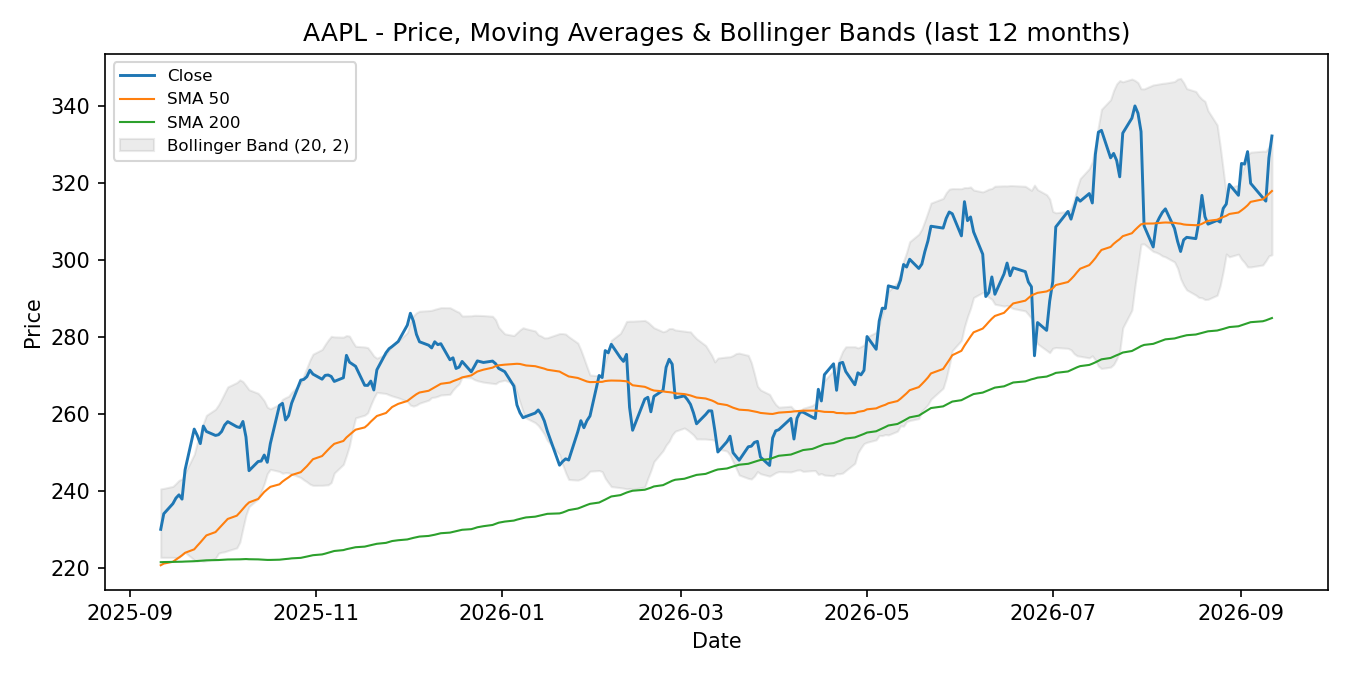

In [17]:
from IPython.display import HTML, display
with open(html_path, encoding="utf-8") as f:
    html_report = f.read()
display(HTML(html_report))


from IPython.display import IFrame

# Replace 'your_file.html' with the path to your file
IFrame(src=html_path, width='100%', height=500)


from IPython.display import HTML, display

# Read the HTML file contents
# with open(html_path, 'r', encoding='utf-8') as file:
#     html_report = file.read()

# # Render the HTML content
# display(HTML(html_report))


## 4. Summary

- **Task 1A**: ✅ 2yr OHLCV fetch, 4 first-principles indicators (verified against manual
  calculation), ≥10 headlines with RSS fallback, robust summary dict, no unhandled
  exceptions on missing data.
- **Task 1B**: ✅ Per-headline structured sentiment JSON, confidence-weighted aggregation,
  indicator-reasoned Buy/Hold/Sell signal, all Pydantic-validated with graceful failure
  handling on both network errors and malformed/unparsable LLM output. Prompts fully
  separated from business logic (see `src/prompts.py`).
- **Bonus**: ✅ One-page Markdown + styled HTML brief with embedded chart and risk
  disclaimer.

See `CITATIONS.md` for AI-assistance citations and `README.md` for the full requirement
mapping and known limitations.
